dataset: https://www.kaggle.com/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset<br>
github: https://github.com/keoner/IT3385_mlops/tree/Keoni<br>
website: https://it3385-mlops-hool.onrender.com/

# 1.0 Import Libraries & Data

In [1]:
import pandas as pd
from extra.utils import load_config
import mlflow
from pycaret.classification import *
from pycaret.regression import *
from pycaret.anomaly import AnomalyExperiment
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
cfg = load_config()

Config loaded successfully!

data:
  raw_path: ../data/raw/smart_manufacturing_data.csv
  interim_path: ../data/interim/cleaned.csv
  processed_path: ../data/processed/features.csv
  target_column: maintenance_required
  temporal_target_column: time_to_failure_minutes
  anomaly_target_column: failure_type
cleaning: null
features:
  rolling_window_size: 5
  sensor_columns:
  - temperature
  - vibration
  - humidity
  - pressure
  - energy_consumption
model:
  n_jobs: 2
  session_id: 42
  train_size: 0.8
  ignore_features:
  - failure_type
  - downtime_risk
  - anomaly_flag
  - machine_status
  - predicted_remaining_life
  - time_to_failure_minutes
  temporal_ignore_features:
  - failure_type
  - downtime_risk
  - anomaly_flag
  - machine_status
  - predicted_remaining_life
  - maintenance_required
  anomaly_models:
  - iforest
  - knn
  - lof
  - pca
  anomaly_ignore_features:
  - failure_type
  - downtime_risk
  - anomaly_flag
  - machine_status
  - predicted_remaining_life
  - time_to

In [3]:
print(cfg.model.anomaly_ignore_features)

['failure_type', 'downtime_risk', 'anomaly_flag', 'machine_status', 'predicted_remaining_life', 'time_to_failure_minutes', 'maintenance_required']


In [4]:
df_cleaned = pd.read_csv(cfg.data.interim_path, parse_dates=["timestamp"])
df_feat = pd.read_csv(cfg.data.processed_path, parse_dates=["timestamp"])

# Lesser rows now because I clipped the imcomplete data out.
print(df_cleaned.shape)
print(df_feat.shape)

(99137, 14)
(99137, 37)


In [110]:
def train_model(data, name, target):
    exp = ClassificationExperiment()

    exp.setup(
        data=data,
        target=target,
        session_id=cfg.model.session_id,
        train_size=cfg.model.train_size,
        ignore_features=cfg.model.ignore_features,
        experiment_name=f"{cfg.mlflow.experiment_name}_{name}",
        log_experiment=False,
        html=False,
        verbose=False
    )

    model = exp.compare_models(verbose=False)
    results = exp.pull().copy()

    return exp, model, results

In [111]:
cleaned_exp, cleaned_model, cleaned_results = train_model(df_cleaned, "Classification_Cleaned", cfg.data.target_column)

In [112]:
print("=== Cleaned Only ===")
print(cleaned_results)

=== Cleaned Only ===
                                 Model  Accuracy     AUC  Recall   Prec.  \
rf            Random Forest Classifier    0.8918  0.7291  0.4523  0.9991   
ada               Ada Boost Classifier    0.8918  0.7279  0.4522  0.9993   
gbc       Gradient Boosting Classifier    0.8917  0.7249  0.4523  0.9982   
et              Extra Trees Classifier    0.8896  0.7292  0.4461  0.9882   
knn             K Neighbors Classifier    0.8639  0.7170  0.4064  0.8092   
nb                         Naive Bayes    0.8499  0.7233  0.2573  0.9351   
lr                 Logistic Regression    0.8310  0.6960  0.1498  0.9603   
lda       Linear Discriminant Analysis    0.8300  0.6961  0.1441  0.9641   
ridge                 Ridge Classifier    0.8090  0.6961  0.0321  1.0000   
qda    Quadratic Discriminant Analysis    0.8026  0.0000  0.0000  0.0000   
dummy                 Dummy Classifier    0.8026  0.5000  0.0000  0.0000   
dt            Decision Tree Classifier    0.7963  0.6964  0.5313  0

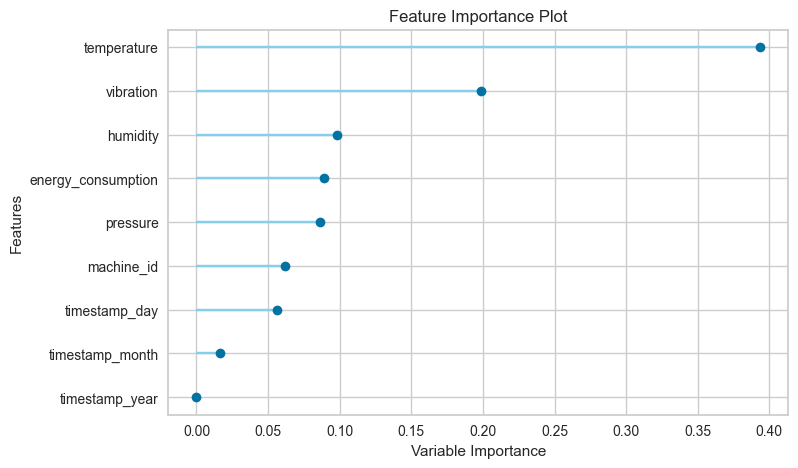

In [113]:
cleaned_exp.plot_model(cleaned_model, plot="feature")


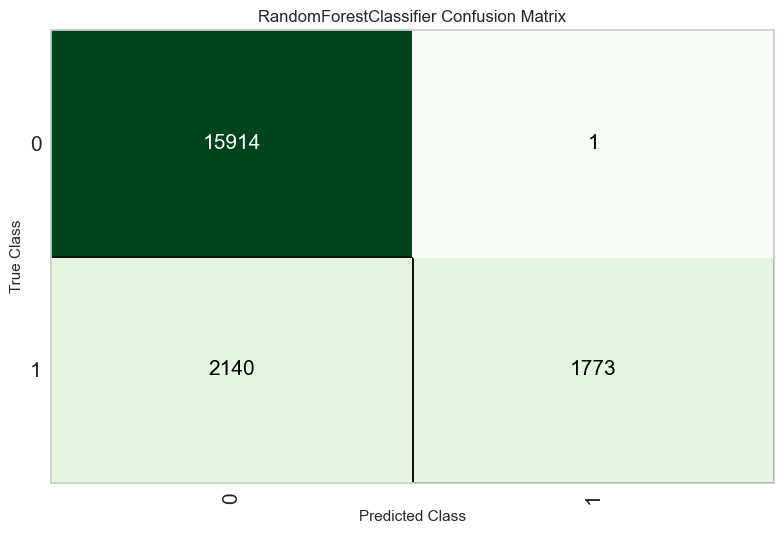

In [114]:
cleaned_exp.plot_model(cleaned_model, plot="confusion_matrix")

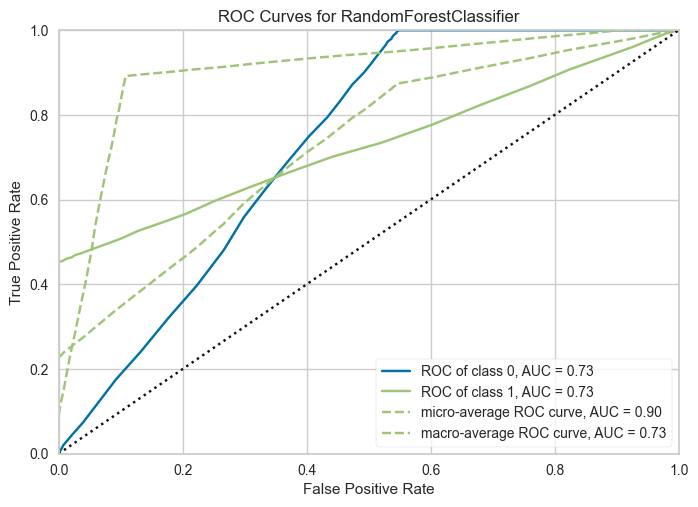

In [115]:
cleaned_exp.plot_model(cleaned_model, plot="auc")

In [116]:
eng_exp, eng_model, eng_results = train_model(df_feat, "Classification_Engineered", cfg.data.target_column)

In [117]:
print("\n=== Feature Engineered ===")
print(eng_results)


=== Feature Engineered ===
                                 Model  Accuracy     AUC  Recall   Prec.  \
ada               Ada Boost Classifier    0.8923  0.7300  0.4546  0.9992   
rf            Random Forest Classifier    0.8922  0.7326  0.4547  0.9976   
gbc       Gradient Boosting Classifier    0.8922  0.7312  0.4546  0.9985   
et              Extra Trees Classifier    0.8888  0.7319  0.4470  0.9770   
knn             K Neighbors Classifier    0.8281  0.6622  0.2496  0.6739   
lda       Linear Discriminant Analysis    0.8281  0.7003  0.1302  0.9922   
lr                 Logistic Regression    0.8270  0.7146  0.1236  1.0000   
qda    Quadratic Discriminant Analysis    0.8212  0.7067  0.4127  0.5647   
nb                         Naive Bayes    0.8102  0.7160  0.5073  0.5197   
ridge                 Ridge Classifier    0.8078  0.7003  0.0259  1.0000   
dummy                 Dummy Classifier    0.8026  0.5000  0.0000  0.0000   
dt            Decision Tree Classifier    0.7952  0.6947  0.

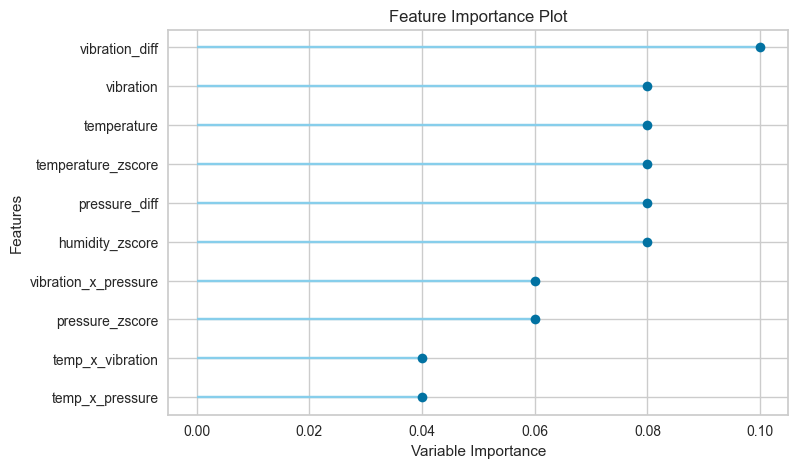

In [118]:
eng_exp.plot_model(eng_model, plot="feature")

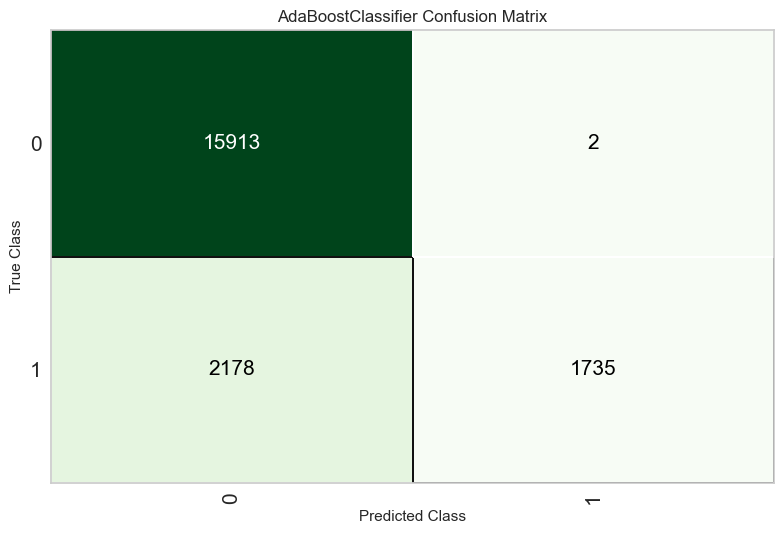

In [119]:
eng_exp.plot_model(eng_model, plot="confusion_matrix")

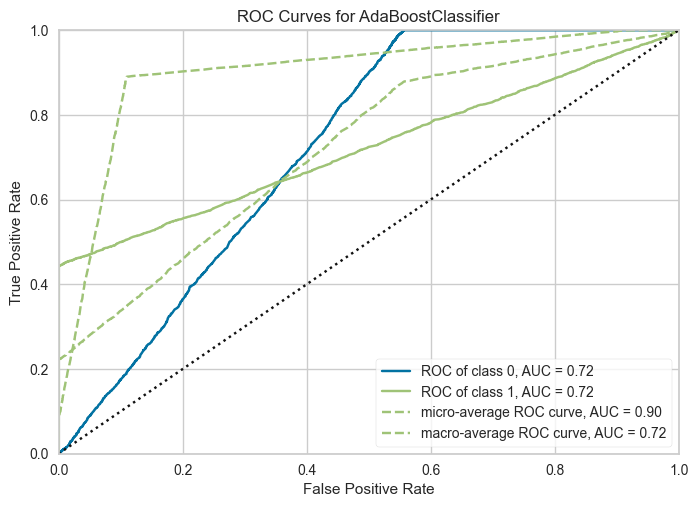

In [120]:
eng_exp.plot_model(eng_model, plot="auc")

## Evaluation of Predicting Classifiers with Feature Engineering
The engineered features were not beneficial for this dataset and model setup. Rather than improving predictive performance, they introduced additional complexity by increasing the number of features without providing meaningful new information. This resulted in longer training times while offering little to no improvement in evaluation metrics, and in some cases, slightly reduced model performance. Overall, the engineered features were not effective, and a simple data cleaning approach using the original features produced better results. Therefore, the cleaned dataset was selected as the final dataset for model development due to its comparable predictive performance, lower computational cost, and simpler feature set.

# Temporal Regression

In [121]:
df_cleaned = df_cleaned.sort_values("timestamp").reset_index(drop=True)
dates = sorted(df_cleaned["timestamp"].dt.normalize().unique())
train_dates = dates[:60]
test_dates = dates[60:]

train = df_cleaned[df_cleaned["timestamp"].dt.normalize().isin(train_dates)]
test = df_cleaned[df_cleaned["timestamp"].dt.normalize().isin(test_dates)]

In [122]:
def train_temporal_model(train, test, name, target):
    exp = RegressionExperiment()

    exp.setup(
        data=train,
        test_data=test,
        target=target,
        session_id=cfg.model.session_id,
        ignore_features=cfg.model.temporal_ignore_features,
        experiment_name=f"{cfg.mlflow.experiment_name}_{name}",
        log_experiment=False,

        data_split_shuffle=False,
        data_split_stratify=False,
        fold_strategy="timeseries",
        fold=5,
        fold_shuffle=False,

        html=False,
        verbose=False
    )

    model = exp.compare_models(verbose=False)
    results = exp.pull().copy()

    return exp, model, results


cleaned_time_exp, cleaned_time_model, cleaned_time_results = train_temporal_model(train, test, "Regression_Cleaned", cfg.data.temporal_target_column)

In [123]:
display(cleaned_time_results)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,172.9335,60659.8710,246.0109,0.0568,2.2429,4.3020,2.844
en,Elastic Net,182.5840,63441.5585,251.6203,0.0131,2.5816,3.9839,0.040
br,Bayesian Ridge,182.7356,63448.3472,251.6346,0.0130,2.5830,3.9926,0.034
lasso,Lasso Regression,182.7661,63456.0531,251.6504,0.0128,2.5830,3.9949,0.038
llar,Lasso Least Angle Regression,182.7661,63456.0525,251.6504,0.0128,2.5830,3.9949,0.030
lr,Linear Regression,183.2776,63496.3266,251.7337,0.0122,2.5870,4.0255,0.036
ridge,Ridge Regression,183.2775,63496.3156,251.7337,0.0122,2.5870,4.0255,0.038
lar,Least Angle Regression,183.2776,63496.3266,251.7337,0.0122,2.5870,4.0255,0.038
omp,Orthogonal Matching Pursuit,182.3780,63531.7036,251.8030,0.0116,2.5826,3.9427,0.028
et,Extra Trees Regressor,180.4716,64211.7002,253.1534,0.0008,2.2551,4.5185,2.022


                         Model       MAE         MSE      RMSE      R2  \
0  Gradient Boosting Regressor  175.5325  63015.3342  251.0286  0.0536   

    RMSLE    MAPE  
0  2.2737  4.4251  


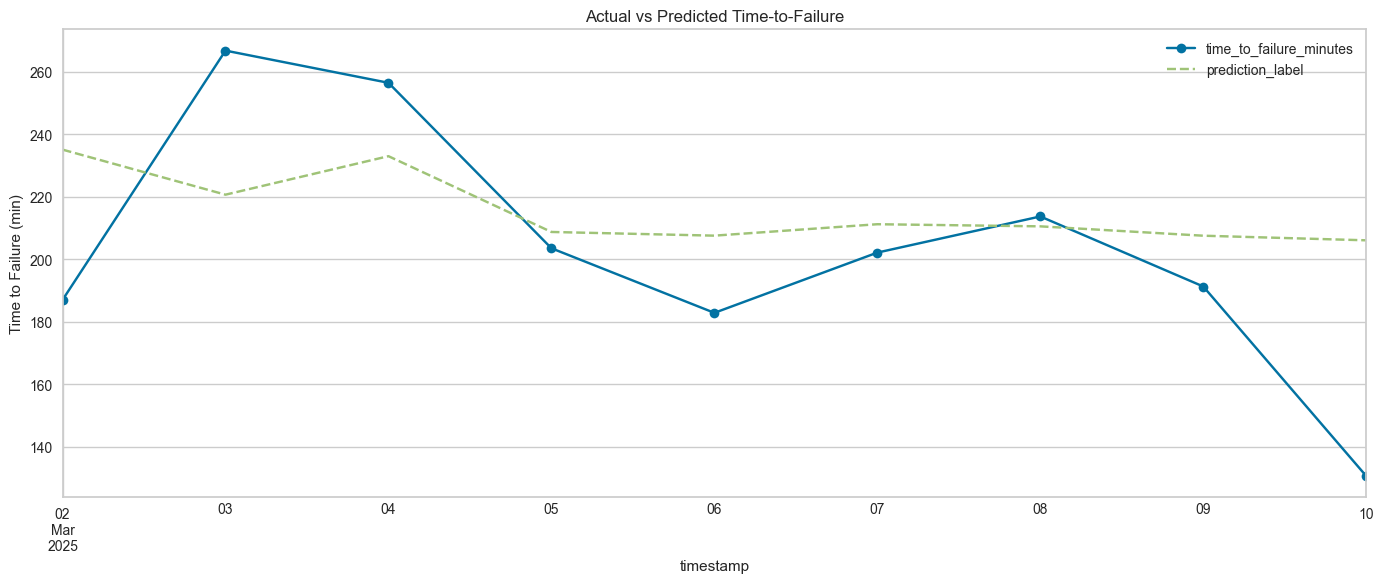

In [124]:
predictions = cleaned_time_exp.predict_model(cleaned_time_model, data=test)
predictions["timestamp"] = pd.to_datetime(test["timestamp"].values)

daily = predictions.set_index("timestamp")[
    [cfg.data.temporal_target_column, "prediction_label"]
].resample("D").mean()

daily.plot(figsize=(14, 6), style=["-o", "--x"])
plt.title("Actual vs Predicted Time-to-Failure")
plt.ylabel("Time to Failure (min)")
plt.tight_layout()
plt.show()

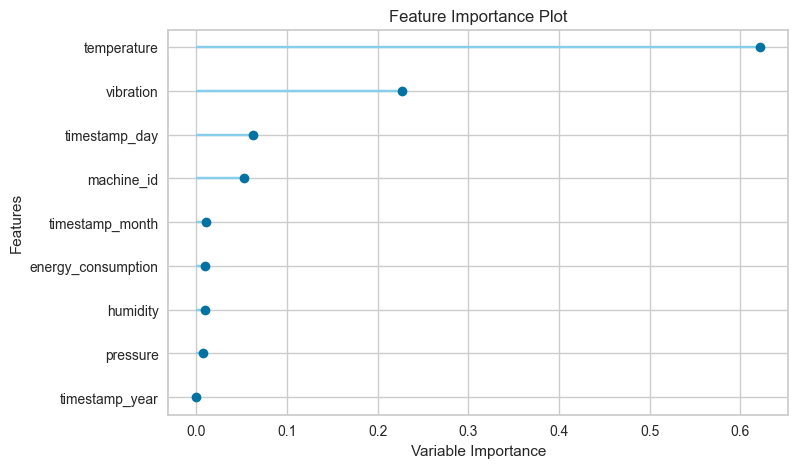

In [125]:
cleaned_time_exp.plot_model(cleaned_time_model, plot="feature")

In [126]:
df_feat = df_feat.sort_values("timestamp").reset_index(drop=True)
dates = sorted(df_feat["timestamp"].dt.normalize().unique())
train_dates = dates[:60]
test_dates = dates[60:]

train = df_feat[df_feat["timestamp"].dt.normalize().isin(train_dates)]
test = df_feat[df_feat["timestamp"].dt.normalize().isin(test_dates)]

In [127]:
eng_time_exp, eng_time_model, eng_time_results = train_temporal_model(train, test, "Regression_Engineered", cfg.data.temporal_target_column)

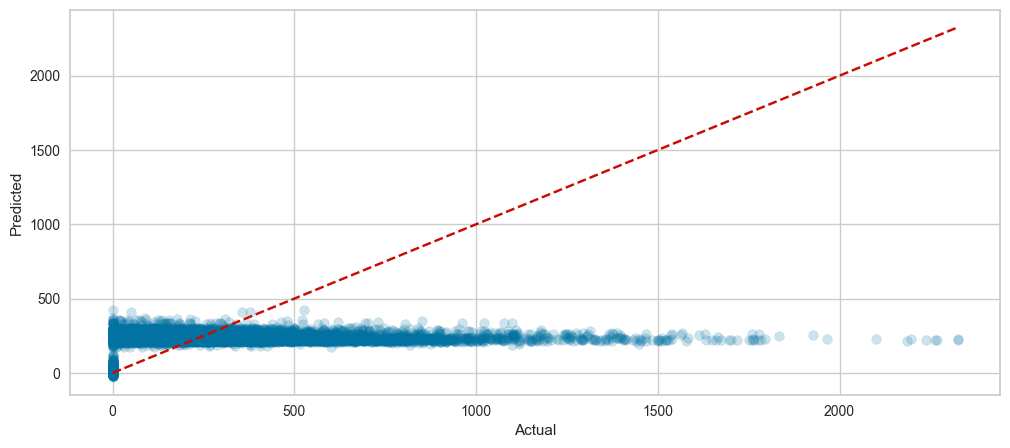

In [128]:
plt.figure(figsize=(12, 5))
plt.scatter(
    predictions[cfg.data.temporal_target_column],
    predictions["prediction_label"],
    alpha=0.2,
)
plt.plot(
    [predictions[cfg.data.temporal_target_column].min(),
     predictions[cfg.data.temporal_target_column].max()],
    [predictions[cfg.data.temporal_target_column].min(),
     predictions[cfg.data.temporal_target_column].max()],
    "r--",
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [129]:
display(eng_time_results)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,172.4357,60638.4262,245.9759,0.0570,2.2453,4.2571,21.760
et,Extra Trees Regressor,179.9282,62788.5581,250.3426,0.0229,2.2354,4.6539,9.582
en,Elastic Net,182.6524,63462.6854,251.6605,0.0128,2.5820,3.9902,0.250
br,Bayesian Ridge,182.4913,63461.4360,251.6574,0.0128,2.5815,3.9733,0.114
lasso,Lasso Regression,182.8375,63490.1371,251.7155,0.0123,2.5832,4.0012,0.260
llar,Lasso Least Angle Regression,182.8374,63490.1204,251.7154,0.0123,2.5832,4.0012,0.110
rf,Random Forest Regressor,180.0503,63470.8400,251.6936,0.0123,2.1590,4.6636,40.162
omp,Orthogonal Matching Pursuit,182.4469,63553.7319,251.8480,0.0113,2.5830,3.9384,0.108
ridge,Ridge Regression,183.4316,63588.6666,251.9076,0.0109,2.5868,4.0294,0.126
lr,Linear Regression,183.4368,63590.6330,251.9113,0.0108,2.5868,4.0293,0.118


                         Model       MAE         MSE      RMSE      R2  \
0  Gradient Boosting Regressor  174.5823  62604.8064  250.2095  0.0598   

    RMSLE    MAPE  
0  2.2776  4.4026  


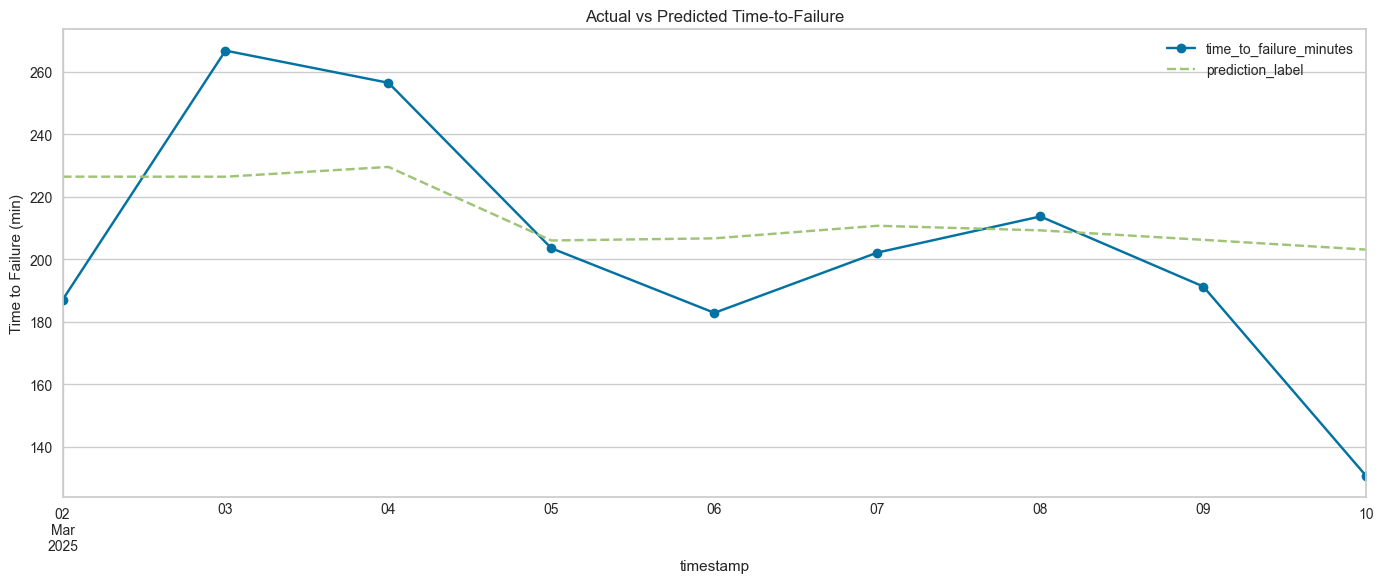

In [134]:
predictions = eng_time_exp.predict_model(eng_time_model, data=test)
predictions["timestamp"] = pd.to_datetime(test["timestamp"].values)

daily = predictions.set_index("timestamp")[
    [cfg.data.temporal_target_column, "prediction_label"]
].resample("D").mean()

daily.plot(figsize=(14, 6), style=["-o", "--x"])
plt.title("Actual vs Predicted Time-to-Failure")
plt.ylabel("Time to Failure (min)")
plt.tight_layout()
plt.show()

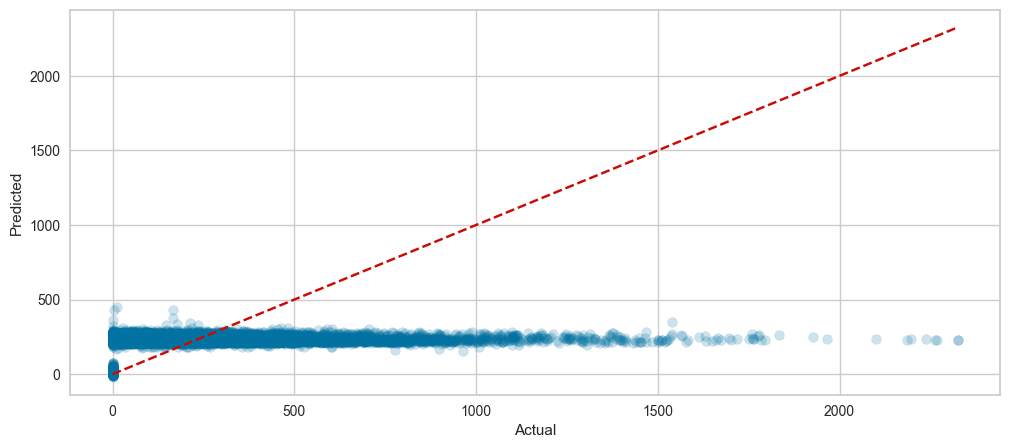

In [135]:
plt.figure(figsize=(12, 5))
plt.scatter(
    predictions[cfg.data.temporal_target_column],
    predictions["prediction_label"],
    alpha=0.2,
)
plt.plot(
    [predictions[cfg.data.temporal_target_column].min(),
     predictions[cfg.data.temporal_target_column].max()],
    [predictions[cfg.data.temporal_target_column].min(),
     predictions[cfg.data.temporal_target_column].max()],
    "r--",
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

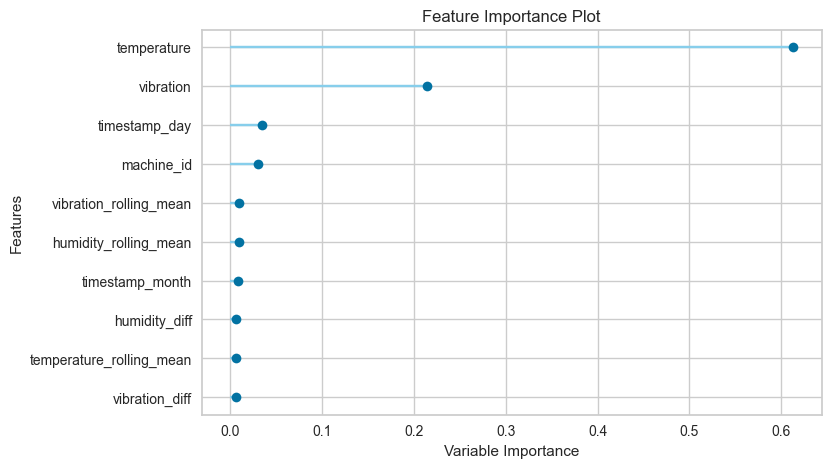

In [136]:
eng_time_exp.plot_model(eng_time_model, plot="feature")

Regression isn't good on this dataset

In [151]:
def train_anomaly_model(data, name):
    models= cfg.model.anomaly_models
    train, test = train_test_split(data, test_size=0.2, random_state=cfg.model.session_id)
    train = data[(data["failure_type"] == "Normal") & (data["maintenance_required"] == 0)]
    y_true = test["maintenance_required"]
    test = test.drop(columns=cfg.model.anomaly_ignore_features)

    exp = AnomalyExperiment()
    exp.setup(
        data=train,
        session_id=cfg.model.session_id,
        ignore_features=cfg.model.anomaly_ignore_features,
        experiment_name=f"{cfg.mlflow.experiment_name}_{name}",
        log_experiment=False,
        html=False,
        verbose=False
    )

    results = []
    fraction_grid=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
    for m in models:
        for frac in fraction_grid:
            model = exp.create_model(m, fraction=frac, verbose=False)
            pred = exp.predict_model(model, data=test)

            results.append({
                "model": m,
                "fraction": frac,
                "precision": precision_score(y_true, pred["Anomaly"]),
                "recall": recall_score(y_true, pred["Anomaly"]),
                "f1": f1_score(y_true, pred["Anomaly"]),
            })

    results = pd.DataFrame(results).sort_values("f1", ascending=False)
    return exp, results


cleaned_anom_exp, cleaned_anom_results = train_anomaly_model(df_cleaned, "Anomaly_Cleaned")
eng_anom_exp, eng_anom_results = train_anomaly_model(df_feat, "Anomaly_Engineered")

In [ ]:
# Classification
cleaned_tuned_class= cleaned_exp.tune_model(cleaned_model, optimize='F1', n_iter=20)
eng_tuned_class = eng_exp.tune_model(eng_model, optimize='F1', n_iter=20)

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 20 candidates, totalling 200 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8909  0.7236  0.4473  1.0000  0.6181  0.5651  0.6275
1       0.8908  0.7233  0.4466  1.0000  0.6175  0.5644  0.6270
2       0.8902  0.7217  0.4435  1.0000  0.6144  0.5612  0.6246
3       0.8936  0.7303  0.4607  1.0000  0.6308  0.5783  0.6378
4       0.8928  0.7283  0.4569  1.0000  0.6272  0.5745  0.6349
5       0.8922  0.7274  0.4543  0.9986  0.6245  0.5716  0.6323
6       0.8908  0.7232  0.4466  1.0000  0.6175  0.5644  0.6270
7       0.8967  0.7388  0.4770  1.0000  0.6459  0.5942  0.6501
8       0.8916  0.7256  0.4508  1.0000  0.6215  0.5685  0.6302
9       0.8890  0.7191  0.4383  0.9985  0.6092  0.5557  0.6200
Mean    0.8919  0.7261  0.4522  0.9997  0.6227  0.5698  0.6311
Std     0.0020  0.0052  0.0103  

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 20 candidates, totalling 200 fits


      Accuracy     AUC  Recall  Prec.      F1   Kappa     MCC
Fold                                                         
0       0.8936  0.7304  0.4607    1.0  0.6308  0.5783  0.6378
1       0.8913  0.7246  0.4492    1.0  0.6199  0.5670  0.6290
2       0.8933  0.7297  0.4594    1.0  0.6296  0.5771  0.6368
3       0.8878  0.7162  0.4313    1.0  0.6027  0.5490  0.6151
4       0.8951  0.7341  0.4684    1.0  0.6379  0.5858  0.6436
5       0.8872  0.7140  0.4281    1.0  0.5996  0.5458  0.6127
6       0.8936  0.7303  0.4607    1.0  0.6308  0.5783  0.6378
7       0.8924  0.7276  0.4553    1.0  0.6257  0.5730  0.6336
8       0.8942  0.7321  0.4642    1.0  0.6341  0.5817  0.6404
9       0.8950  0.7344  0.4677    1.0  0.6374  0.5852  0.6431
Mean    0.8923  0.7273  0.4545    1.0  0.6248  0.5721  0.6330
Std     0.0027  0.0067  0.0135    0.0  0.0129  0.0134  0.0104


In [ ]:
# Regression
cleaned_tuned_reg = cleaned_time_exp.tune_model(cleaned_time_model, optimize='R2', n_iter=20)
eng_tuned_reg= eng_time_exp.tune_model(eng_time_model, optimize='R2', n_iter=20)

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 20 candidates, totalling 100 fits


           MAE         MSE      RMSE      R2   RMSLE    MAPE
Fold                                                        
0     179.2015  64131.2743  253.2415  0.0559  2.3569  4.6781
1     174.8228  61558.5669  248.1100  0.0439  2.3333  4.4622
2     179.1854  68923.5790  262.5330  0.0517  2.2291  3.9036
3     169.9758  55313.1437  235.1875  0.0651  2.2617  4.3231
4     164.5226  53266.2384  230.7948  0.0686  2.2300  4.2018
Mean  173.5416  60638.5605  245.9734  0.0570  2.2822  4.3137
Std     5.6495   5734.0769   11.6476  0.0089  0.0532  0.2591


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
           MAE         MSE      RMSE      R2   RMSLE    MAPE
Fold                                                        
0     177.1705  64743.5335  254.4475  0.0469  2.3209  4.4989
1     173.4088  61246.3493  247.4800  0.0487  2.2950  4.3844
2     179.3021  68845.6723  262.3846  0.0528  2.2211  3.9083
3     169.8797  55267.3906  235.0902  0.0659  2.2841  4.2817
4     165.8201  53411.4669  231.1092  0.0660  2.2535  4.2835
Mean  173.1162  60702.8825  246.1023  0.0561  2.2749  4.2714
Std     4.8682   5755.6330   11.6851  0.0083  0.0345  0.1983


In [154]:
display(cleaned_anom_results.head(10))
display(eng_anom_results.head(10))

,model,fraction,precision,recall,f1
12,lof,0.05,0.714400,0.455496,0.556300
13,lof,0.10,0.581355,0.512114,0.544542
7,knn,0.10,0.598162,0.464677,0.523037
14,lof,0.15,0.493648,0.554960,0.522512
8,knn,0.15,0.524961,0.514920,0.519892
9,knn,0.20,0.470980,0.558786,0.511140
6,knn,0.05,0.715226,0.388166,0.503224
15,lof,0.20,0.436505,0.587350,0.500815
10,knn,0.25,0.427810,0.593981,0.497384
16,lof,0.25,0.395854,0.623310,0.484200


,model,fraction,precision,recall,f1
8,knn,0.15,0.499862,0.460342,0.479288
9,knn,0.20,0.452484,0.508799,0.478992
10,knn,0.25,0.411504,0.545524,0.469130
7,knn,0.10,0.563845,0.400918,0.468624
11,knn,0.30,0.380675,0.583780,0.460842
14,lof,0.15,0.436518,0.432288,0.434393
15,lof,0.20,0.389495,0.482275,0.430948
6,knn,0.05,0.672292,0.314971,0.428968
16,lof,0.25,0.358497,0.530477,0.427851
13,lof,0.10,0.504905,0.367508,0.425387


In [ ]:
print("True = Original better, False = Tuned better")
print("cleaned_class:",  cleaned_tuned_class.get_params() == cleaned_model.get_params())
print("eng_class:",  eng_tuned_class.get_params() == eng_model.get_params())
print("cleaned_reg:",  cleaned_tuned_reg.get_params() == cleaned_time_model.get_params())
print("eng_reg:",  eng_tuned_reg.get_params() == eng_time_model.get_params())

cleaned_class: True
eng_class: False
cleaned_reg: False
eng_reg: True


In [158]:
# Classification
cleaned_exp.save_model(cleaned_model, "../models/classification_cleaned")
eng_exp.save_model(eng_tuned_class, "../models/classification_engineered")

# Regression
cleaned_time_exp.save_model(cleaned_tuned_reg, "../models/regression_cleaned")
eng_time_exp.save_model(eng_tuned_reg, "../models/regression_engineered")

# Anomaly detection
cleaned_anom_best_row = cleaned_anom_results.iloc[0]
eng_anom_best_row = eng_anom_results.iloc[0]

cleaned_anom_model = cleaned_anom_exp.create_model(
    cleaned_anom_best_row["model"], fraction=cleaned_anom_best_row["fraction"], verbose=False
)
eng_anom_model = eng_anom_exp.create_model(
    eng_anom_best_row["model"], fraction=eng_anom_best_row["fraction"], verbose=False
)

cleaned_anom_exp.save_model(cleaned_anom_model, "../models/anomaly_cleaned")
eng_anom_exp.save_model(eng_anom_model, "../models/anomaly_engineered")
print("done")

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
done
